In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# #**230051L - ARACHCHI.A.D.I.D**

In [31]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
im = cv.imread("/kaggle/input/datasets/isithadinujaya/cv-images/emma.jpg",cv.IMREAD_GRAYSCALE)
t1 = np.linspace(0, 50, num=51)
t2 = np.linspace(100, 255, num=100)
t3 = np.linspace(150, 255, num=105)
t = np.concatenate((t1, t2, t3)).astype(np.uint8)
g = t[im]
breakpoints2=np.array([[0,40],[50,90],[100,170],[150,180],[255,255]],dtype=np.float32)
t2=np.interp(np.arange(256),breakpoints2[:,0],breakpoints2[:,1])
g2=t2[im].astype(np.uint8)

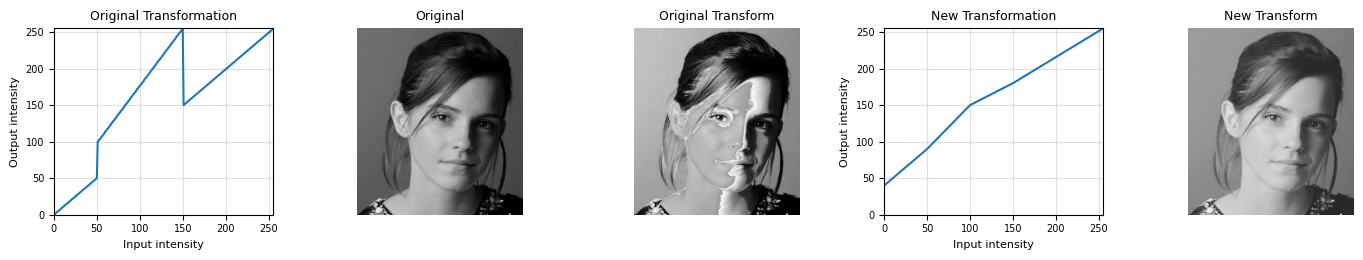

In [29]:

fig,ax=plt.subplots(1,5,figsize=(14,2.7))
ax[0].plot(np.arange(256),t,linewidth=1.5)
ax[0].set_title("Original Transformation",fontsize=9)
ax[0].set_xlabel("Input intensity",fontsize=8)
ax[0].set_ylabel("Output intensity",fontsize=8)
ax[0].set_xlim(0,255)
ax[0].set_ylim(0,255)
ax[0].tick_params(labelsize=7)
ax[0].grid(True,alpha=0.4)
ax[1].imshow(im,cmap="gray",vmin=0,vmax=255)
ax[1].set_title("Original",fontsize=9)
ax[1].axis("off")
ax[2].imshow(g,cmap="gray",vmin=0,vmax=255)
ax[2].set_title("Original Transform",fontsize=9)
ax[2].axis("off")
ax[3].plot(np.arange(256),t2,linewidth=1.5)
ax[3].set_title("New Transformation",fontsize=9)
ax[3].set_xlabel("Input intensity",fontsize=8)
ax[3].set_ylabel("Output intensity",fontsize=8)
ax[3].set_xlim(0,255)
ax[3].set_ylim(0,255)
ax[3].tick_params(labelsize=7)
ax[3].grid(True,alpha=0.4)
ax[4].imshow(g2,cmap="gray",vmin=0,vmax=255)
ax[4].set_title("New Transform",fontsize=9)
ax[4].axis("off")
plt.tight_layout()
plt.show()

To enhance the image we brighten up the dark range intensities to light range. Therefore low intensitie were mapped to high intensities while for the high intensities were maintained a near one to one mapping

# # **Question 2**

In [48]:
brain = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/q2.jpeg",cv.IMREAD_GRAYSCALE)
def step_intensity_transform(im,mu,width):
    x=np.arange(256,dtype=np.float32)
    T=np.zeros(256,dtype=np.uint8)
    T[(x>=mu-width)&(x<=mu+width)]=255
    transformed=T[im]
    return transformed,T
mu_white=150
width_white=25
white_matter,T_white=step_intensity_transform(brain,mu_white,width_white)
mu_gray=200
width_gray=20
gray_matter,T_gray=step_intensity_transform(brain,mu_gray,width_gray)
x=np.arange(256)

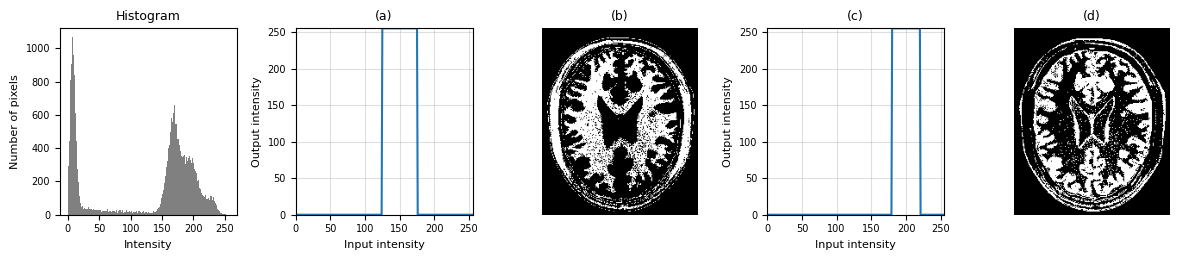

In [49]:

fig, ax = plt.subplots(1, 5, figsize=(12, 2.7))

ax[0].hist(
    brain.ravel(),
    bins=256,
    range=(0, 256),
    color="gray"
)
ax[0].set_xlabel("Intensity", fontsize=8)
ax[0].set_ylabel("Number of pixels", fontsize=8)
ax[0].set_title("Histogram", fontsize=9)
ax[0].tick_params(labelsize=7)

ax[1].plot(x, T_white, linewidth=1.5)
ax[1].set_xlabel("Input intensity", fontsize=8)
ax[1].set_ylabel("Output intensity", fontsize=8)
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[1].set_title("(a)", fontsize=9)
ax[1].tick_params(labelsize=7)
ax[1].grid(alpha=0.4)

ax[2].imshow(white_matter, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("(b)", fontsize=9)
ax[2].axis("off")

ax[3].plot(x, T_gray, linewidth=1.5)
ax[3].set_xlabel("Input intensity", fontsize=8)
ax[3].set_ylabel("Output intensity", fontsize=8)
ax[3].set_xlim(0, 255)
ax[3].set_ylim(0, 255)
ax[3].set_title("(c)", fontsize=9)
ax[3].tick_params(labelsize=7)
ax[3].grid(alpha=0.4)

ax[4].imshow(gray_matter, cmap="gray", vmin=0, vmax=255)
ax[4].set_title("(d)", fontsize=9)
ax[4].axis("off")

plt.tight_layout()
plt.show()

Identified the color range that grey and white matter pixels are and mapped them to high intensity while lowering the rest of the intensities to a zero value

# #**Question 03**

In [3]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg")
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)
gamma = 0.6
L_corrected = 255 * (L.astype(np.float32) / 255.0) ** gamma
L_corrected = np.clip(L_corrected, 0, 255).astype(np.uint8)
lab_corrected = cv.merge((L_corrected, a, b))
corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
corrected_rgb = cv.cvtColor(corrected, cv.COLOR_BGR2RGB)

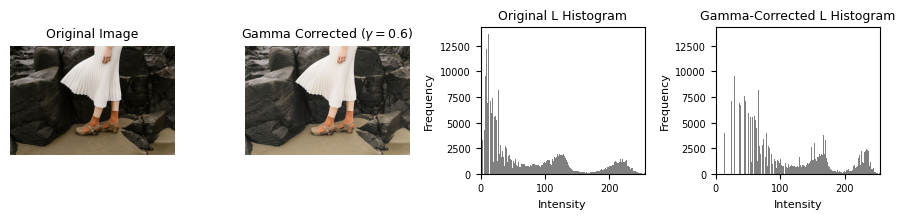

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(9, 2.3))

ax[0].imshow(img_rgb)
ax[0].set_title("Original Image", fontsize=9)
ax[0].axis("off")

ax[1].imshow(corrected_rgb)
ax[1].set_title(rf"Gamma Corrected ($\gamma={gamma}$)",fontsize=9)
ax[1].axis("off")

ax[2].hist(L.ravel(),bins=256,range=(0, 256),color="gray")
ax[2].set_title("Original L Histogram", fontsize=9)
ax[2].set_xlabel("Intensity", fontsize=8)
ax[2].set_ylabel("Frequency", fontsize=8)
ax[2].tick_params(labelsize=7)
ax[2].set_xlim(0, 255)

ax[3].hist(L_corrected.ravel(),bins=256,range=(0, 256),color="gray")
ax[3].set_title("Gamma-Corrected L Histogram", fontsize=9)
ax[3].set_xlabel("Intensity", fontsize=8)
ax[3].set_ylabel("Frequency", fontsize=8)
ax[3].tick_params(labelsize=7)
ax[3].set_xlim(0, 255)

plt.tight_layout()
plt.show()

We used a gamma value less than 1 because the image has lots of darker spotss which needed to be lighten. Therefore through gamma correction lower intensities through a non linear mmapping has been mapped to brighter intensities making the image more visible

## **Question 04**

In [22]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.441.jpeg")
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float32)
    y = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma**2))
    return np.clip(y, 0, 255).astype(np.uint8)
a = 0.5
sigma = 70
S_new = vibrance_transform(S, a, sigma)
hsv_new = cv.merge((H, S_new, V))
enhanced = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)
original_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
enhanced_rgb = cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)
x = np.arange(256, dtype=np.float32)
y = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma**2))
y = np.clip(y, 0, 255)

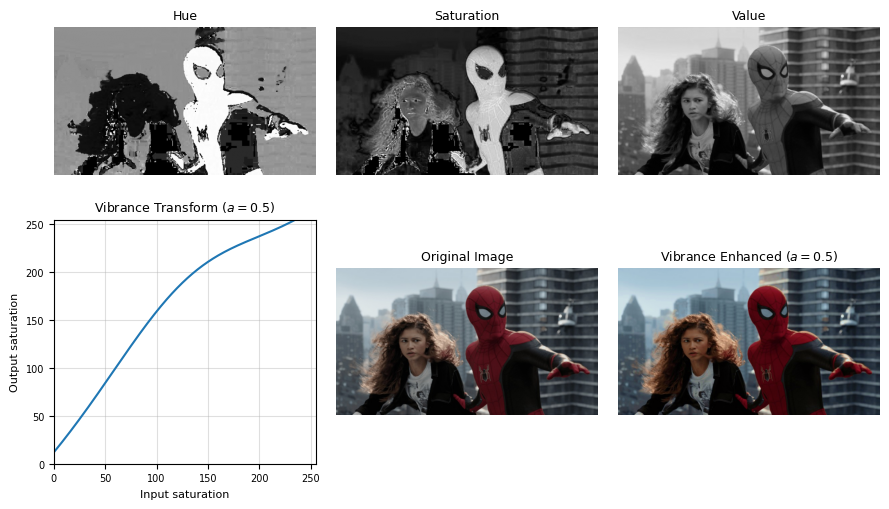

In [23]:
fig, ax = plt.subplots(2, 3, figsize=(9, 5.5))

ax[0, 0].imshow(H, cmap="gray")
ax[0, 0].set_title("Hue", fontsize=9)
ax[0, 0].axis("off")

ax[0, 1].imshow(S, cmap="gray", vmin=0, vmax=255)
ax[0, 1].set_title("Saturation", fontsize=9)
ax[0, 1].axis("off")

ax[0, 2].imshow(V, cmap="gray", vmin=0, vmax=255)
ax[0, 2].set_title("Value", fontsize=9)
ax[0, 2].axis("off")

ax[1, 0].plot(x, y, linewidth=1.5)
ax[1, 0].set_title(rf"Vibrance Transform ($a={a}$)",fontsize=9)
ax[1, 0].set_xlabel("Input saturation", fontsize=8)
ax[1, 0].set_ylabel("Output saturation", fontsize=8)
ax[1, 0].set_xlim(0, 255)
ax[1, 0].set_ylim(0, 255)
ax[1, 0].tick_params(labelsize=7)
ax[1, 0].grid(alpha=0.4)

ax[1, 1].imshow(original_rgb)
ax[1, 1].set_title("Original Image", fontsize=9)
ax[1, 1].axis("off")

ax[1, 2].imshow(enhanced_rgb)
ax[1, 2].set_title(rf"Vibrance Enhanced ($a={a}$)",fontsize=9)
ax[1, 2].axis("off")

plt.tight_layout()
plt.show()

In this case we only enhances the stauration while keeping the hue and value same. Therefore colors became more vivid while the image's brightness was kept moderately.

# # **Question 5**

In [24]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/shells.tif",cv.IMREAD_GRAYSCALE)
def histogram_equalization(img):
    hist = np.bincount(img.ravel(), minlength=256)
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0][0]
    N = img.size
    if N == cdf_min:
        return img.copy()
    T = np.round(255 * (cdf - cdf_min) / (N - cdf_min))
    T = np.clip(T, 0, 255).astype(np.uint8)
    return T[img]
equalized = histogram_equalization(img)

[ WARN:0@3153.413] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


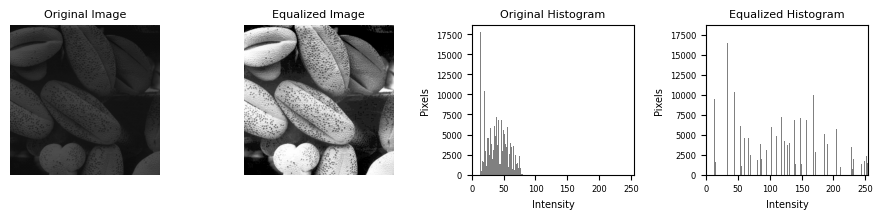

In [25]:
fig, ax = plt.subplots(1, 4, figsize=(9, 2.3))
ax[0].imshow(img, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original Image", fontsize=8)
ax[0].axis("off")
ax[1].imshow(equalized, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Equalized Image", fontsize=8)
ax[1].axis("off")
ax[2].hist(img.ravel(), bins=256, range=(0, 256), color="gray")
ax[2].set_title("Original Histogram", fontsize=8)
ax[2].set_xlabel("Intensity", fontsize=7)
ax[2].set_ylabel("Pixels", fontsize=7)
ax[2].set_xlim(0, 255)
ax[2].tick_params(labelsize=6)
ax[3].hist(equalized.ravel(), bins=256, range=(0, 256), color="gray")
ax[3].set_title("Equalized Histogram", fontsize=8)
ax[3].set_xlabel("Intensity", fontsize=7)
ax[3].set_ylabel("Pixels", fontsize=7)
ax[3].set_xlim(0, 255)
ax[3].tick_params(labelsize=6)
plt.tight_layout()
plt.show()

First the Histogram of the grayscale image is calculated. Then we calculate its CDF. Then through intensity mappping we widden the range of intensity distibution. As we can see the new histogram  is muvh more spread out in the intensity and as a result the image becomes more clearer

# # **Question 06**

In [50]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg")
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)
_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)
foreground = cv.bitwise_and(img, img, mask=mask)
foreground_pixels = V[mask > 0]
hist = np.bincount(foreground_pixels.ravel(),minlength=256)
cdf = np.cumsum(hist)
cdf_min = cdf[cdf > 0][0]
N = foreground_pixels.size
if N == cdf_min:
    T = np.arange(256, dtype=np.uint8)
else:
    T = np.round(255 * (cdf - cdf_min) / (N - cdf_min))
    T = np.clip(T, 0, 255).astype(np.uint8)
V_equalized = V.copy()
V_equalized[mask > 0] = T[V[mask > 0]]
hsv_equalized = cv.merge((H, S, V_equalized))
result = cv.cvtColor(hsv_equalized, cv.COLOR_HSV2BGR)
original_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
foreground_rgb = cv.cvtColor(foreground, cv.COLOR_BGR2RGB)
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

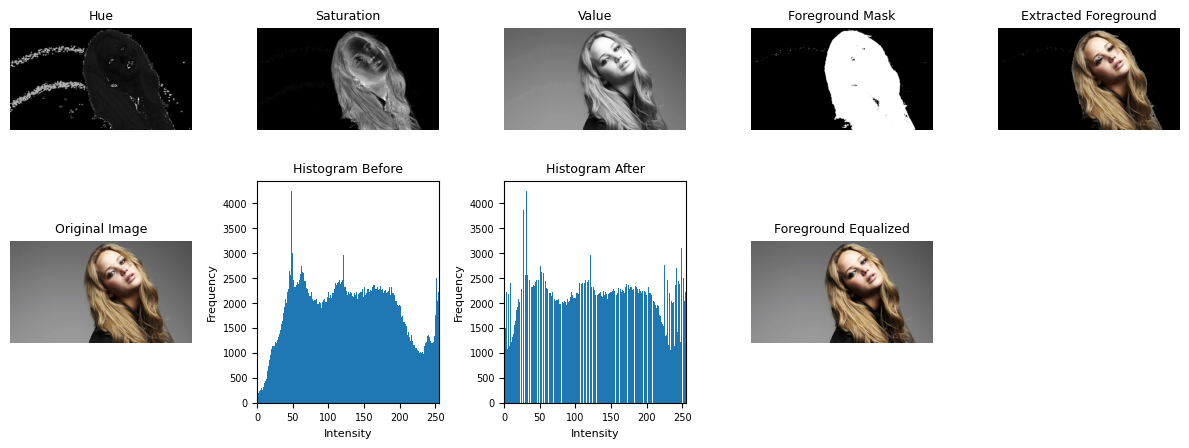

In [55]:

hist_before=np.bincount(V[mask>0].ravel(),minlength=256)
hist_after=np.bincount(V_equalized[mask>0].ravel(),minlength=256)
fig,ax=plt.subplots(2,5,figsize=(12,5))
ax[0,0].imshow(H,cmap="gray")
ax[0,0].set_title("Hue",fontsize=9)
ax[0,0].axis("off")
ax[0,1].imshow(S,cmap="gray",vmin=0,vmax=255)
ax[0,1].set_title("Saturation",fontsize=9)
ax[0,1].axis("off")
ax[0,2].imshow(V,cmap="gray",vmin=0,vmax=255)
ax[0,2].set_title("Value",fontsize=9)
ax[0,2].axis("off")
ax[0,3].imshow(mask,cmap="gray",vmin=0,vmax=255)
ax[0,3].set_title("Foreground Mask",fontsize=9)
ax[0,3].axis("off")
ax[0,4].imshow(foreground_rgb)
ax[0,4].set_title("Extracted Foreground",fontsize=9)
ax[0,4].axis("off")
ax[1,0].imshow(original_rgb)
ax[1,0].set_title("Original Image",fontsize=9)
ax[1,0].axis("off")
ax[1,1].bar(np.arange(256),hist_before,width=1)
ax[1,1].set_title("Histogram Before",fontsize=9)
ax[1,1].set_xlabel("Intensity",fontsize=8)
ax[1,1].set_ylabel("Frequency",fontsize=8)
ax[1,1].set_xlim(0,255)
ax[1,1].tick_params(labelsize=7)
ax[1,2].bar(np.arange(256),hist_after,width=1)
ax[1,2].set_title("Histogram After",fontsize=9)
ax[1,2].set_xlabel("Intensity",fontsize=8)
ax[1,2].set_ylabel("Frequency",fontsize=8)
ax[1,2].set_xlim(0,255)
ax[1,2].tick_params(labelsize=7)
ax[1,3].imshow(result_rgb)
ax[1,3].set_title("Foreground Equalized",fontsize=9)
ax[1,3].axis("off")
ax[1,4].axis("off")
plt.tight_layout()
plt.show()

Initially the histogram shows us that the darker intenity pixel poppulation is low. Andafter the equalizwation the  more pixels a\has got darker values. Same goes with the light pixels as well.

# **Question 07**

In [28]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg",cv.IMREAD_GRAYSCALE)
img_float = img.astype(np.float32)
Gx = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)
Gy = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)
def normalize_magnitude(magnitude):
    """Normalize a gradient magnitude image to the range 0–255."""
    return cv.normalize(magnitude,None,0,255,cv.NORM_MINMAX).astype(np.uint8)
sobel_x = cv.filter2D(img_float, -1, Gx,borderType=cv.BORDER_CONSTANT)
sobel_y = cv.filter2D(img_float, -1, Gy,borderType=cv.BORDER_CONSTANT)
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
magnitude_display = normalize_magnitude(magnitude)
def my_filter2d(img, kernel):
    img = img.astype(np.float32)
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    padded = np.pad(img,((pad_h, pad_h), (pad_w, pad_w)),mode="constant")
    output = np.zeros_like(img, dtype=np.float32)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + kh, j:j + kw]
            output[i, j] = np.sum(region * kernel)
    return output
my_sobel_x = my_filter2d(img, Gx)
my_sobel_y = my_filter2d(img, Gy)
my_magnitude = np.sqrt(my_sobel_x**2 + my_sobel_y**2)
my_magnitude_display = normalize_magnitude(my_magnitude)
smooth_col = np.array([[1],[2],[1]], dtype=np.float32)
diff_row = np.array([[1, 0, -1]], dtype=np.float32)
smooth_row = np.array([[1, 2, 1]], dtype=np.float32)
diff_col = np.array([[ 1],[ 0],[-1]], dtype=np.float32)
temp_x = cv.filter2D(img_float, -1, smooth_col,borderType=cv.BORDER_CONSTANT)
sep_sobel_x = cv.filter2D(temp_x, -1, diff_row,borderType=cv.BORDER_CONSTANT)
temp_y = cv.filter2D(img_float, -1, smooth_row,borderType=cv.BORDER_CONSTANT)
sep_sobel_y = cv.filter2D(temp_y, -1, diff_col,borderType=cv.BORDER_CONSTANT)
sep_magnitude = np.sqrt(sep_sobel_x**2 + sep_sobel_y**2)
sep_magnitude_display = normalize_magnitude(sep_magnitude)

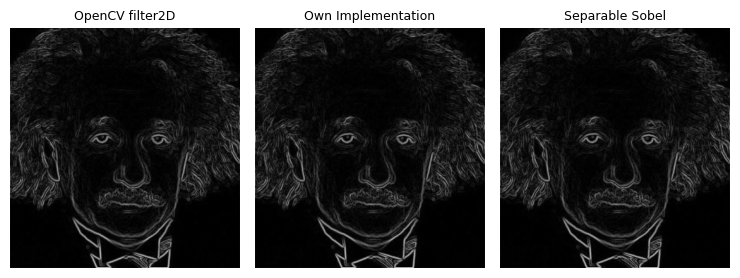

In [29]:

fig, ax = plt.subplots(1, 3, figsize=(7.5, 2.8))

ax[0].imshow(magnitude_display, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("OpenCV filter2D", fontsize=9)
ax[0].axis("off")

ax[1].imshow(my_magnitude_display, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Own Implementation", fontsize=9)
ax[1].axis("off")

ax[2].imshow(sep_magnitude_display, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("Separable Sobel", fontsize=9)
ax[2].axis("off")

plt.tight_layout()
plt.show()

All three Sobel filters have identified the maajor edges accurately. However minor differences are thee and they are mainly due to numerical precision used in the methods. Out of the three methods, separable soblekernel is preferred because it used two one dimensional filtering instead of 3x3 convolutional filtering methods making it computationally far more efficient than  other methods

# # **Question 08**

In [30]:
def zoom_nearest(img, scale):
    h, w = img.shape[:2]
    new_h = int(h * scale)
    new_w = int(w * scale)
    if img.ndim == 2:
        output = np.zeros((new_h, new_w), dtype=img.dtype)
    else:
        output = np.zeros((new_h, new_w, img.shape[2]),dtype=img.dtype)
    for i in range(new_h):
        for j in range(new_w):
            src_i = int(round(i / scale))
            src_j = int(round(j / scale))
            src_i = min(src_i, h - 1)
            src_j = min(src_j, w - 1)
            output[i, j] = img[src_i, src_j]
    return output
def zoom_bilinear(img, scale):
    h, w = img.shape[:2]
    new_h = int(h * scale)
    new_w = int(w * scale)
    if img.ndim == 2:
        output = np.zeros((new_h, new_w), dtype=np.float32)
    else:
        output = np.zeros((new_h, new_w, img.shape[2]),dtype=np.float32)
    img_float = img.astype(np.float32)
    for i in range(new_h):
        for j in range(new_w):
            x = i / scale
            y = j / scale
            x0 = min(int(np.floor(x)), h - 1)
            y0 = min(int(np.floor(y)), w - 1)
            x1 = min(x0 + 1, h - 1)
            y1 = min(y0 + 1, w - 1)
            dx = x - x0
            dy = y - y0
            Q11 = img_float[x0, y0]
            Q12 = img_float[x0, y1]
            Q21 = img_float[x1, y0]
            Q22 = img_float[x1, y1]
            output[i, j] = ((1 - dx) * (1 - dy) * Q11+ (1 - dx) * dy * Q12+ dx * (1 - dy) * Q21+ dx * dy * Q22)
    return np.clip(output, 0, 255).astype(np.uint8)
def zoom_image(img, scale, method="nearest"):
    if method == "nearest":
        return zoom_nearest(img, scale)
    if method == "bilinear":
        return zoom_bilinear(img, scale
def normalized_ssd(reference, test):
    reference = reference.astype(np.float64)
    test = test.astype(np.float64)
    numerator = np.sum((reference - test) ** 2)
    denominator = np.sum(reference**2)
    return numerator / denominator

Image 1
Nearest-neighbour NSSD : 0.022590
Bilinear NSSD          : 0.017719

Image 2
Nearest-neighbour NSSD : 0.010240
Bilinear NSSD          : 0.007757


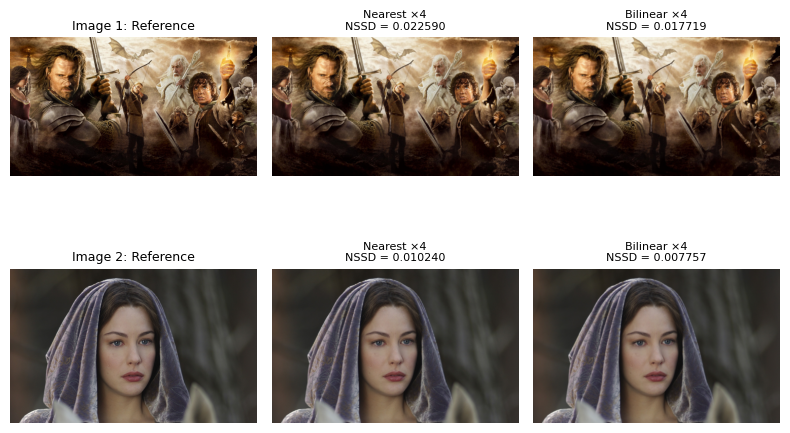

In [31]:
base_path = "/kaggle/input/datasets/isithadinujaya/vision-data-set/images/"
original_1 = cv.imread(base_path + "im01.png")
small_1 = cv.imread(base_path + "im01small.png")
original_2 = cv.imread(base_path + "im02.png")
small_2 = cv.imread(base_path + "im02small.png")
scale = 4
nearest_1 = zoom_image(small_1, scale, "nearest")
bilinear_1 = zoom_image(small_1, scale, "bilinear")
nearest_2 = zoom_image(small_2, scale, "nearest")
bilinear_2 = zoom_image(small_2, scale, "bilinear")
ssd_nearest_1 = normalized_ssd(original_1, nearest_1)
ssd_bilinear_1 = normalized_ssd(original_1, bilinear_1)
ssd_nearest_2 = normalized_ssd(original_2, nearest_2)
ssd_bilinear_2 = normalized_ssd(original_2, bilinear_2)
print("Image 1")
print(f"Nearest-neighbour NSSD : {ssd_nearest_1:.6f}")
print(f"Bilinear NSSD          : {ssd_bilinear_1:.6f}")
print("\nImage 2")
print(f"Nearest-neighbour NSSD : {ssd_nearest_2:.6f}")
print(f"Bilinear NSSD          : {ssd_bilinear_2:.6f}")
fig, ax = plt.subplots(2, 3, figsize=(8, 5.5))
ax[0, 0].imshow(cv.cvtColor(original_1, cv.COLOR_BGR2RGB))
ax[0, 0].set_title("Image 1: Reference", fontsize=9)
ax[0, 0].axis("off")
ax[0, 1].imshow(cv.cvtColor(nearest_1, cv.COLOR_BGR2RGB))
ax[0, 1].set_title(f"Nearest ×4\nNSSD = {ssd_nearest_1:.6f}",fontsize=8)
ax[0, 1].axis("off")
ax[0, 2].imshow(cv.cvtColor(bilinear_1, cv.COLOR_BGR2RGB))
ax[0, 2].set_title(f"Bilinear ×4\nNSSD = {ssd_bilinear_1:.6f}",fontsize=)
ax[0, 2].axis("off")
ax[1, 0].imshow(cv.cvtColor(original_2, cv.COLOR_BGR2RGB))
ax[1, 0].set_title("Image 2: Reference", fontsize=9)
ax[1, 0].axis("off")
ax[1, 1].imshow(cv.cvtColor(nearest_2, cv.COLOR_BGR2RGB))
ax[1, 1].set_title(f"Nearest ×4\nNSSD = {ssd_nearest_2:.6f}",fontsize=8)
ax[1, 1].axis("off")
ax[1, 2].imshow(cv.cvtColor(bilinear_2, cv.COLOR_BGR2RGB))
ax[1, 2].set_title(f"Bilinear ×4\nNSSD = {ssd_bilinear_2:.6f}",fontsize=8)
ax[1, 2].axis("off")
plt.tight_layout()
plt.show()

Observing the values we got it seems bilinear transformation is much more accurate than the nearest neighbour method. The reason for bilinear performs well is that nearest neighbour methods uses the same pixels in the nearest neighbour while in the bilinear method we predict the pixel value making it much more closer to the real large image 

# # **Question 09**

In [32]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.43 (1).jpeg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w = img.shape[:2]
rect = (10, 10, w - 20,h - 20 )
mask = np.zeros((h, w), dtype=np.uint8)
bg_model = np.zeros((1, 65), dtype=np.float64)
fg_model = np.zeros((1, 65), dtype=np.float64)
cv.grabCut(img,mask,rect,bg_model,fg_model,5,cv.GC_INIT_WITH_RECT)
final_mask = np.where((mask == cv.GC_FGD) |(mask == cv.GC_PR_FGD),1,0).astype(np.uint8)
background_mask = 1 - final_mask
foreground = img * final_mask[:, :, np.newaxis]
background = img * background_mask[:, :, np.newaxis]
blurred_img = cv.GaussianBlur(img,(31, 31),0)
blurred_background = (blurred_img * background_mask[:, :, np.newaxis])
enhanced = foreground + blurred_background
foreground_rgb = cv.cvtColor(foreground, cv.COLOR_BGR2RGB)
background_rgb = cv.cvtColor(background, cv.COLOR_BGR2RGB)
blurred_background_rgb = cv.cvtColor(blurred_background,cv.COLOR_BGR2RGB)
enhanced_rgb = cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)

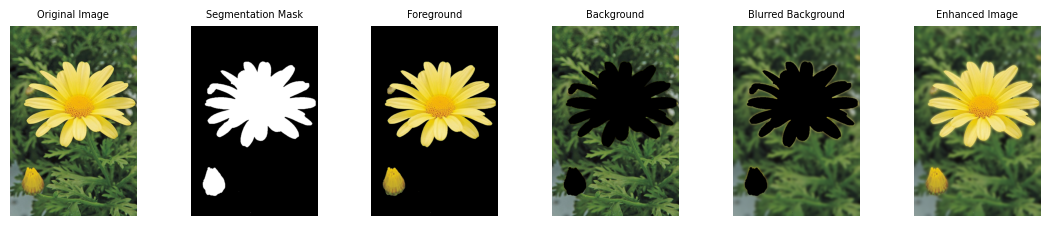

In [33]:
fig, ax = plt.subplots(1, 6, figsize=(11, 2.2))
ax[0].imshow(img_rgb)
ax[0].set_title("Original Image", fontsize=7)
ax[0].axis("off")
ax[1].imshow(final_mask, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Segmentation Mask", fontsize=7)
ax[1].axis("off")
ax[2].imshow(foreground_rgb)
ax[2].set_title("Foreground", fontsize=7)
ax[2].axis("off")
ax[3].imshow(background_rgb)
ax[3].set_title("Background", fontsize=7)
ax[3].axis("off")
ax[4].imshow(blurred_background_rgb)
ax[4].set_title("Blurred Background", fontsize=7)
ax[4].axis("off")
ax[5].imshow(enhanced_rgb)
ax[5].set_title("Enhanced Image", fontsize=7)
ax[5].axis("off")
plt.tight_layout(pad=0.5)
plt.show()

The reason for darkness in the edge is that when we use gaussian bluring for the backgroundt we padded the extracted area with zeroes. So when blurring the edge theese zeros contribute to lower the intensity  in that area when averaging. Therefore it results in the edge becomes darker

# #**Question 10**

In [34]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (3).jpeg")

sigma_s = 5
sigma_r = 30
radius = 5
d = 2 * radius + 1
def my_bilateral_filter(img, sigma_s, sigma_r, radius):
    img_float = img.astype(np.float32)
    h, w, channels = img.shape
    padded = cv.copyMakeBorder(img_float,radius,radius,radius,radius,cv.BORDER_REFLECT)
    output = np.zeros_like(img_float)
    y, x = np.mgrid[-radius:radius + 1,-radius:radius + 1]
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
    for i in range(h):
        for j in range(w):
            region = padded[i:i + 2 * radius + 1,j:j + 2 * radius + 1]
            center = padded[i + radius, j + radius]
            color_distance_sq = np.sum((region - center) ** 2,axis=2)
            range_weights = np.exp(-color_distance_sq / (2 * sigma_r**2))
            weights = spatial_weights * range_weights
            weights_sum = np.sum(weights)
            output[i, j] = np.sum(region * weights[:, :, np.newaxis],axis=(0, 1)) / weights_sum
    return np.clip(output, 0, 255).astype(np.uint8)
def mse(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    return np.mean((img1 - img2) ** 2)
def psnr(img1, img2):
    error = mse(img1, img2)
    if error == 0:
        return float("inf")
    return 10 * np.log10((255.0**2) / error)
bilateral_cv = cv.bilateralFilter(img,d=d,sigmaColor=sigma_r,sigmaSpace=sigma_s,borderType=cv.BORDER_REFLECT)
gaussian = cv.GaussianBlur(img,(d, d), sigmaX=sigma_s,  sigmaY=sigma_s,   borderType=cv.BORDER_REFLECT)
bilateral_own = my_bilateral_filter(  img, sigma_s=sigma_s,sigma_r=sigma_r,  radius=radius)
mse_value = mse(bilateral_cv, bilateral_own)
psnr_value = psnr(bilateral_cv, bilateral_own)

Kernel diameter: 11
sigma_s: 5
sigma_r: 30
MSE between OpenCV and own bilateral filter: 8.665103
PSNR between OpenCV and own bilateral filter: 38.7531 dB


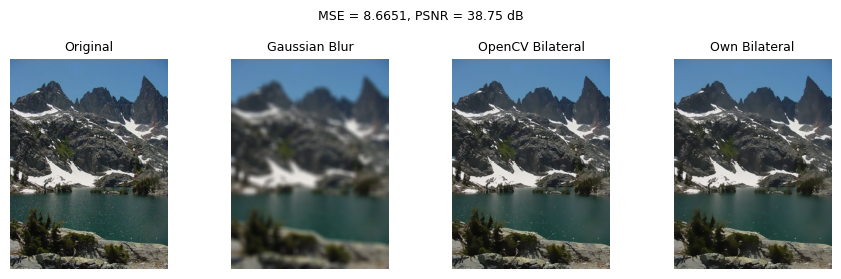

In [35]:
print(f"Kernel diameter: {d}")
print(f"sigma_s: {sigma_s}")
print(f"sigma_r: {sigma_r}")
print(f"MSE between OpenCV and own bilateral filter: {mse_value:.6f}")
print(f"PSNR between OpenCV and own bilateral filter: {psnr_value:.4f} dB")
images = [img,  gaussian,   bilateral_cv,bilateral_own]
titles = ["Original","Gaussian Blur", "OpenCV Bilateral","Own Bilateral"]
fig, ax = plt.subplots(1, 4, figsize=(9, 2.8))
for axis, image, title in zip(ax, images, titles):
    axis.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    axis.set_title(title, fontsize=9)
    axis.axis("off")
fig.suptitle(f"MSE = {mse_value:.4f}, PSNR = {psnr_value:.2f} dB",fontsize=9)
plt.tight_layout()
plt.show()

Eventhough Gaussian Filter was abled to smoothen the image it also blured out the edges. When comparing to Bilateral filter when smoothening it does not blurs the edges. The reason is that bilateral filter adjust the edges accordingly such that its weight depend on intensity similariity and spatial distance.

When compared with MSE its a somewhat smaller value and PSNR is bit high value. The reason is that when implementing our own bilateral filter the facts such as numerical precision and border handling.

**Github** https://github.com/isithadinujaya/Vision-Assignment